In [2]:
%config InlineBackend.figure_format = 'retina' # Make clear on high-res screens
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, roc_auc_score, 
                             precision_recall_curve, 
                             average_precision_score)
from time import time
from sklearn.pipeline import Pipeline

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_values = pd.read_csv('train_values.csv')
train_labels = pd.read_csv('train_labels.csv')
full_train_df = pd.merge(train_values, train_labels, on='building_id')
imbalance_counts = full_train_df['damage_grade'].value_counts().sort_index()
imbalance_pct = full_train_df['damage_grade'].value_counts(normalize=True).sort_index() * 100

report = pd.DataFrame({
    'Count': imbalance_counts,
    'Percentage (%)': imbalance_pct
})

print("--- Data Imbalance Summary ---")
print(report)

--- Data Imbalance Summary ---
               Count  Percentage (%)
damage_grade                        
1              25124        9.640792
2             148259       56.891186
3              87218       33.468022


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# prepare data
X = full_train_df.drop(columns=['building_id', 'damage_grade'])
X = pd.get_dummies(X, drop_first=False)  
y = full_train_df['damage_grade']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# prediction
preds = model.predict(X_test)

# evaluation
f1 = f1_score(y_test, preds, average='weighted')
print("Baseline F1:", f1)
print("X shape after dummies:", X.shape)

Baseline F1: 0.7061978343944493
X shape after dummies: (260601, 68)


In [8]:
def run_model(X, y):
    X = pd.get_dummies(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return f1_score(y_test, preds, average='weighted')


results = {}

# no geo
X_no_geo = full_train_df.drop(columns=[
    'building_id', 'damage_grade',
    'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id'
])
results['no_geo'] = run_model(X_no_geo, full_train_df['damage_grade'])

# only geo_level_1
X_geo1 = full_train_df.drop(columns=[
    'building_id', 'damage_grade',
    'geo_level_2_id', 'geo_level_3_id'
])
results['geo_level_1'] = run_model(X_geo1, full_train_df['damage_grade'])

# only geo_level_2
X_geo2 = full_train_df.drop(columns=[
    'building_id', 'damage_grade',
    'geo_level_1_id', 'geo_level_3_id'
])
results['geo_level_2'] = run_model(X_geo2, full_train_df['damage_grade'])

# only geo_level_3
X_geo3 = full_train_df.drop(columns=[
    'building_id', 'damage_grade',
    'geo_level_1_id', 'geo_level_2_id'
])
results['geo_level_3'] = run_model(X_geo3, full_train_df['damage_grade'])

print("Geo Robustness Results:")
print(results)

Geo Robustness Results:
{'no_geo': 0.5767215814609767, 'geo_level_1': 0.6591570666274896, 'geo_level_2': 0.6410212526328954, 'geo_level_3': 0.6110670786337964}


In [9]:
# Step 3: Label robustness

#  binary label
full_train_df['damage_binary'] = (full_train_df['damage_grade'] >= 2).astype(int)

# prepare data
X = full_train_df.drop(columns=['building_id', 'damage_grade', 'damage_binary'])
X = pd.get_dummies(X)
y = full_train_df['damage_binary']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# prediction
preds = model.predict(X_test)

# evaluation
f1 = f1_score(y_test, preds, average='weighted')

print("Binary Label F1:", f1)

Binary Label F1: 0.9172292196212245


In [12]:
import geopandas as gpd

turkey_df = gpd.read_file("Global_GBA_Antakya.shp")

print(turkey_df.columns)

Index(['damage_lev', 'geometry'], dtype='object')


In [14]:
nepal_damage = full_train_df['damage_grade']
turkey_damage = turkey_df['damage_lev']
print(turkey_damage.value_counts())

damage_lev
3    12338
4     4193
1     3742
2     2894
Name: count, dtype: int64


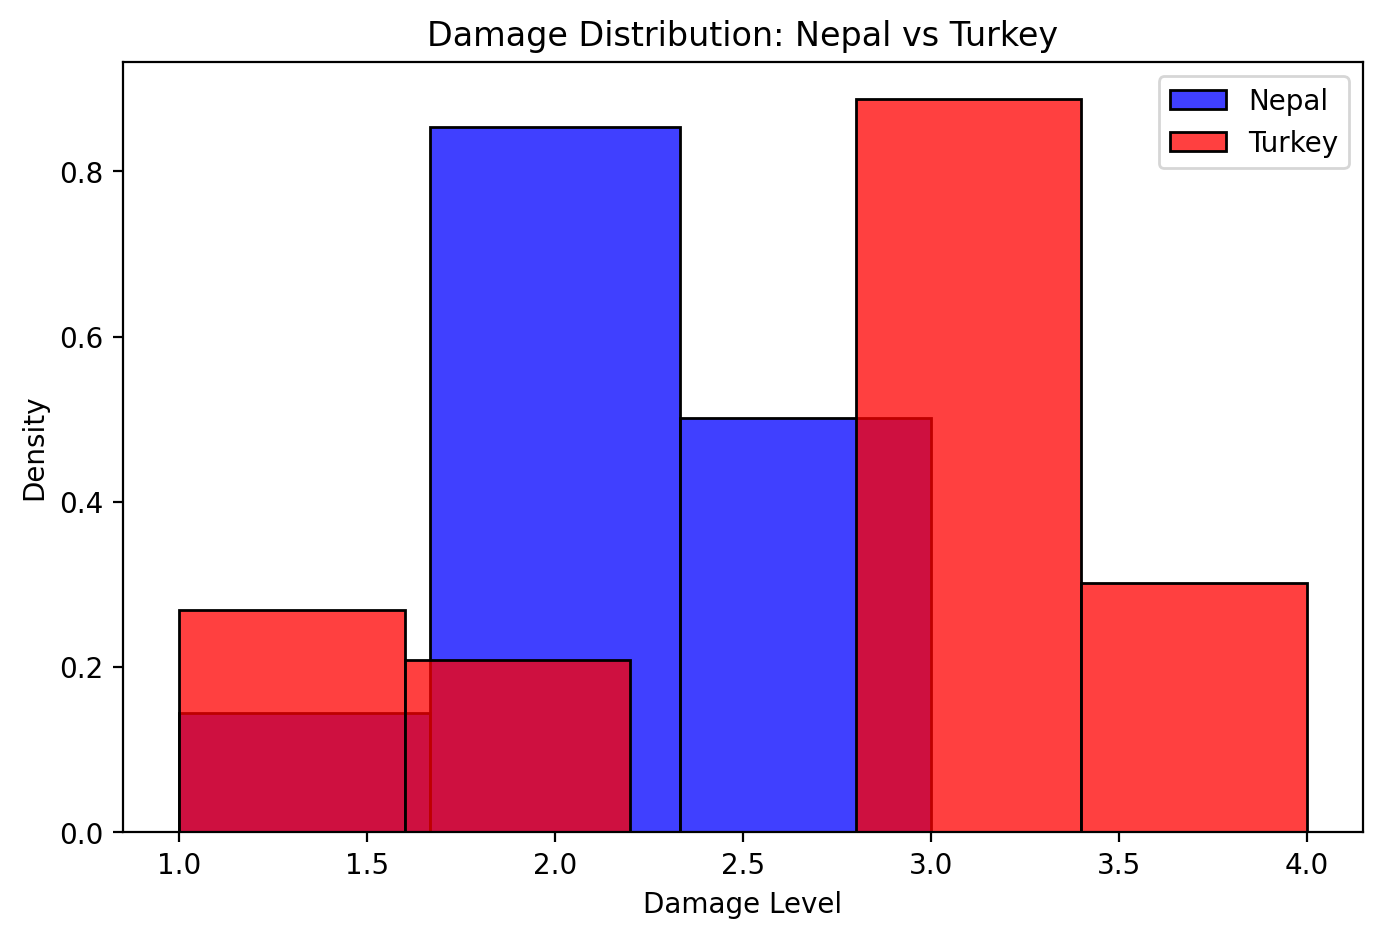

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(nepal_damage, color='blue', label='Nepal', stat='density', bins=3)
sns.histplot(turkey_damage, color='red', label='Turkey', stat='density', bins=5)

plt.legend()
plt.title("Damage Distribution: Nepal vs Turkey")
plt.xlabel("Damage Level")
plt.ylabel("Density")

plt.show()